In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures


In [4]:
N = 50

true_w = 2.0
true_b = 1.0
noise_std = 0.8

x = np.linspace(-3, 3, N)
epsilon = noise_std * np.random.randn(N)
y = true_w * x + true_b + epsilon

print("x shape:", x.shape)
print("epsilon shape:", epsilon.shape)
print("y shape:", y.shape)
print("first 5 x:", x[:5])
print("first 5 y:", y[:5])

x shape: (50,)
epsilon shape: (50,)
y shape: (50,)
first 5 x: [-3.         -2.87755102 -2.75510204 -2.63265306 -2.51020408]
first 5 y: [-3.58875812 -4.43497627 -3.72721369 -2.47259156 -2.52636177]


In [18]:
# Hyperparameters
learning_rate = 0.05
num_iters = 1000

# Initial parameters
w = 0.0
b = 0.0

# History lists for plotting
loss_history = []
w_history = []
b_history = []

for iteration in range(num_iters):
    # Forward pass: prediction
    y_pred = w * x + b

    # Error and loss
    errors = y_pred - y
    loss = np.mean(errors ** 2)

    # Gradients
    grad_w = 2 * np.mean(errors * x)
    grad_b = 2 * np.mean(errors)

    # Parameter update
    w = w - learning_rate * grad_w
    b = b - learning_rate * grad_b

    # Store history
    loss_history.append(loss)
    w_history.append(w)
    b_history.append(b)

print("Final w:", w)
print("Final b:", b)
print("True w:", true_w)
print("True b:", true_b)
print("Final training MSE:", loss_history[-1])

print("\nHistory lengths:")
print("loss_history:", len(loss_history))
print("w_history:", len(w_history))
print("b_history:", len(b_history))

Final w: 1.8117836676013082
Final b: 1.1124474178504773
True w: 2.0
True b: 1.0
Final training MSE: 0.7001392146740105

History lengths:
loss_history: 1000
w_history: 1000
b_history: 1000


In [20]:
ones = np.ones(N)
X = np.column_stack([x, ones])

theta_lstsq, residuals, rank, singular_values = np.linalg.lstsq(
    X,
    y,
    rcond=None
)

w_lstsq = theta_lstsq[0]
b_lstsq = theta_lstsq[1]

y_pred_gd = w * x + b
y_pred_lstsq = X @ theta_lstsq

mse_gd = np.mean((y_pred_gd - y) ** 2)
mse_lstsq = np.mean((y_pred_lstsq - y) ** 2)

print("Gradient descent parameters:")
print("w:", w)
print("b:", b)

print("\nLeast-squares parameters:")
print("w_lstsq:", w_lstsq)
print("b_lstsq:", b_lstsq)

print("\nMSE comparison:")
print("MSE from gradient descent:", mse_gd)
print("MSE from least squares:", mse_lstsq)
print("Absolute MSE difference:", abs(mse_gd - mse_lstsq))

Gradient descent parameters:
w: 1.8117836676013082
b: 1.1124474178504773

Least-squares parameters:
w_lstsq: 1.8117836676013082
b_lstsq: 1.1124474178504775

MSE comparison:
MSE from gradient descent: 0.7001392146740105
MSE from least squares: 0.7001392146740105
Absolute MSE difference: 0.0


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp2_loss_vs_iteration.png


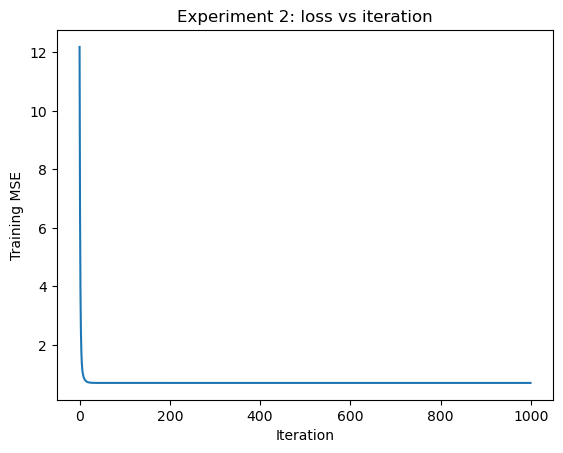

In [22]:
fig, ax = plt.subplots()

ax.plot(loss_history)
ax.set_xlabel("Iteration")
ax.set_ylabel("Training MSE")
ax.set_title("Experiment 2: loss vs iteration")

fig_path = FIGURE_DIR / "exp2_loss_vs_iteration.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp2_parameters_vs_iteration.png


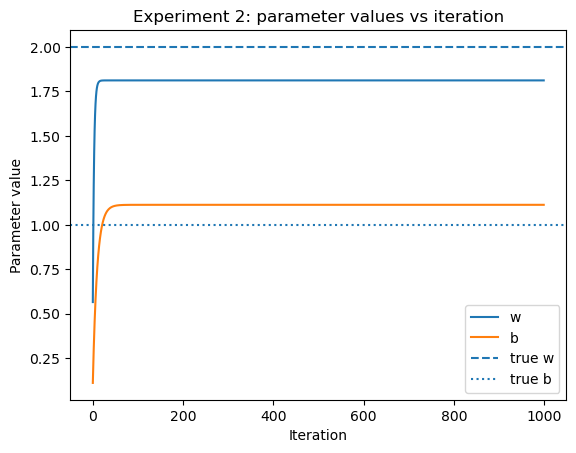

In [31]:
fig, ax = plt.subplots()

ax.plot(w_history, label="w")
ax.plot(b_history, label="b")

ax.axhline(true_w, linestyle="--", label="true w")
ax.axhline(true_b, linestyle=":", label="true b")

ax.set_xlabel("Iteration")
ax.set_ylabel("Parameter value")
ax.set_title("Experiment 2: parameter values vs iteration")
ax.legend()

fig_path = FIGURE_DIR / "exp2_parameters_vs_iteration.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp2_gd_fit_vs_lstsq.png


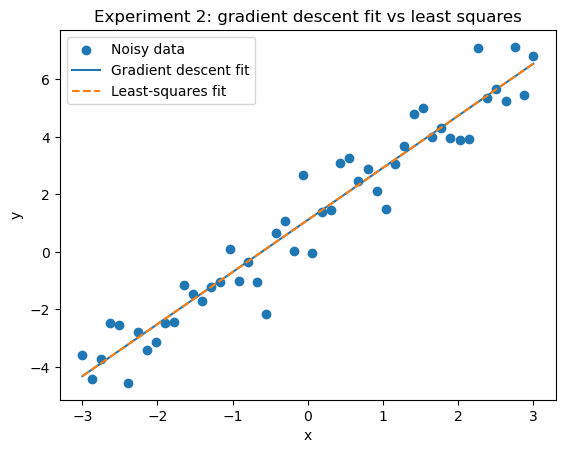

In [33]:
fig, ax = plt.subplots()

ax.scatter(x, y, label="Noisy data")
ax.plot(x, y_pred_gd, label="Gradient descent fit")
ax.plot(x, y_pred_lstsq, linestyle="--", label="Least-squares fit")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Experiment 2: gradient descent fit vs least squares")
ax.legend()

fig_path = FIGURE_DIR / "exp2_gd_fit_vs_lstsq.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [45]:
def run_gradient_descent(x,y,learning_rate, num_iters):
    """
    Run gradient descent for scalar linear regression.
    Returns final parameters and loss history.
    """
    w = 0.0
    b = 0.0

    loss_history = []
    w_history = []
    b_history = []

    for iteration in range(num_iters):
        y_pred = w*x+b
        errors = y_pred-y
        loss = np.mean(errors**2)

        grad_w=2*np.mean(errors*x)
        grad_b=2*np.mean(errors)

        w = w-learning_rate*grad_w
        b = b-learning_rate*grad_b

        loss_history.append(loss)
        w_history.append(w)
        b_history.append(b)

        if not np.isfinite(loss) or loss > 1e6:
            break

    return w, b, np.array(loss_history), np.array(w_history), np.array(b_history)

In [47]:
learning_rates = [.001,.01,.05,.2,.4]
num_iters_compare = 300

results = {}

for lr in learning_rates:
    w_lr, b_lr, loss_lr, w_hist_lr, b_hist_lr = run_gradient_descent(x,y,learning_rate = lr, num_iters=num_iters_compare)

    results[lr] = {'w':w_lr,'b':b_lr,'loss_history':loss_lr, 'w_history':w_hist_lr,'b_history':b_hist_lr,}

    print("learning rate:", lr)
    print("  final w:", w_lr)
    print("  final b:", b_lr)
    print("  final loss:", loss_lr[-1])
    print("  iterations completed:", len(loss_lr))

learning rate: 0.001
  final w: 1.5351418972368442
  final b: 0.5022900238309709
  final loss: 1.3159008103337402
  iterations completed: 300
learning rate: 0.01
  final w: 1.8117836604137798
  final b: 1.1098526279430443
  final loss: 0.7001462252265551
  iterations completed: 300
learning rate: 0.05
  final w: 1.8117836676013082
  final b: 1.1124474178504575
  final loss: 0.7001392146740105
  iterations completed: 300
learning rate: 0.2
  final w: 1.8117836676013084
  final b: 1.1124474178504782
  final loss: 0.7001392146740103
  iterations completed: 300
learning rate: 0.4
  final w: -1162.598463142208
  final b: 1.1124474178431627
  final loss: 1886720.5914998632
  iterations completed: 16


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp2_learning_rate_comparison.png


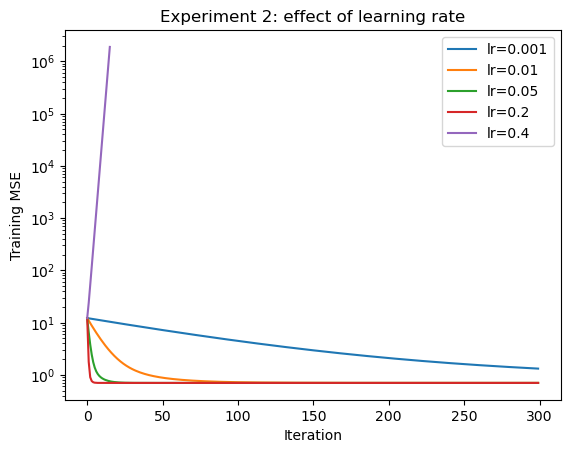

In [49]:
fig, ax = plt.subplots()

for lr in learning_rates:
    ax.plot(results[lr]["loss_history"], label=f"lr={lr}")

ax.set_xlabel("Iteration")
ax.set_ylabel("Training MSE")
ax.set_yscale("log")
ax.set_title("Experiment 2: effect of learning rate")
ax.legend()

fig_path = FIGURE_DIR / "exp2_learning_rate_comparison.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()